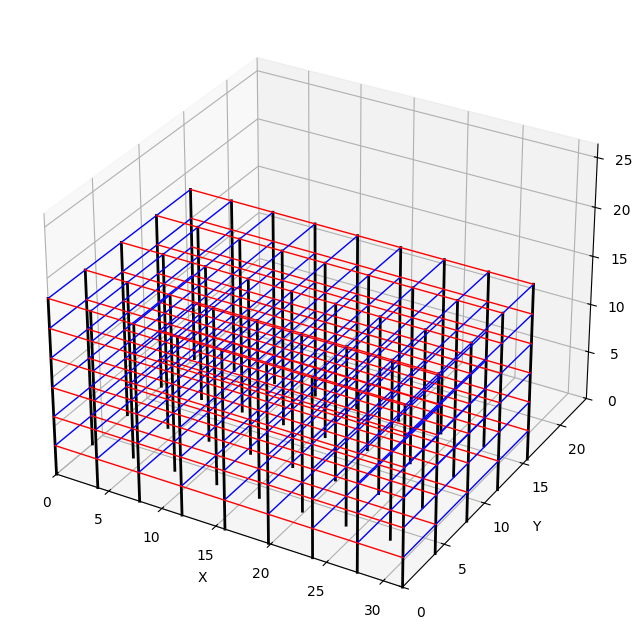

array([ 3.,  6.,  9., 12., 15., 18.])

In [14]:
import json
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
from itertools import product

import matplotlib.pyplot as plt

# Load your JSON data (replace 'your_file.json' with your file path)
with open('inputs/661611279.json', 'r') as f:
    data = json.load(f)

# Example H and B arrays (replace with your actual arrays)
H = np.array(data["frames"]["main_frames"][0][0]["H"])
# Extract B for x from the first main frame
Bx = np.array(data["frames"]["main_frames"][0][0]["L"])
# Extract B for y from the first cross frame
By = np.array(data["frames"]["cross_frames"][0][0]["L"])

# Create a 3D grid (stick figure)
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
# Draw vertical columns (at each grid intersection)
for x, y in product(Bx, By):
    ax.plot([x, x], [y, y], [0, H[-1]], color='k', lw=2)

# Draw beams (horizontal lines at each level)
for z in H:
    for x in Bx:
        ax.plot([x, x], [By[0], By[-1]], [z, z], color='b', lw=1)
    for y in By:
        ax.plot([Bx[0], Bx[-1]], [y, y], [z, z], color='r', lw=1)

# Ensure x, y, and z axes have the same scale
max_range = np.array([Bx.max()-Bx.min(), By.max()-By.min(), H.max()-H.min()]).max() / 2.0

mid_x = (Bx.max()+Bx.min()) * 0.5
mid_y = (By.max()+By.min()) * 0.5
mid_z = (H.max()+H.min()) * 0.5

ax.set_xlim(0, mid_x + max_range)
ax.set_ylim(0, mid_y + max_range)
ax.set_zlim(0, mid_z + max_range)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.show()

H

In [20]:
def plot_rectangle(
    ax,
    x: float,
    y: float,
    x_r: float,
    y_r: float,
    style: dict
) -> None:
    """Draws a rectangle in the XY plane at (x, y) with width x_r and height y_r.

    :param ax: Matplotlib 3D axis to plot on
    :type ax: mpl_toolkits.mplot3d.axes3d.Axes3D
    :param x: Center x-coordinate
    :type x: float
    :param y: Center y-coordinate
    :type y: float
    :param x_r: Rectangle width along x
    :type x_r: float
    :param y_r: Rectangle height along y
    :type y_r: float
    :param style: Plot style dictionary
    :type style: dict
    """
    x_vals = [
        x - x_r / 2, x + x_r / 2, x + x_r / 2, x - x_r / 2, x - x_r / 2
    ]
    y_vals = [
        y - y_r / 2, y - y_r / 2, y + y_r / 2, y + y_r / 2, y - y_r / 2
    ]

    ax.plot(x_vals, y_vals, **style)

    return ax


In [ ]:
def plot_ebam

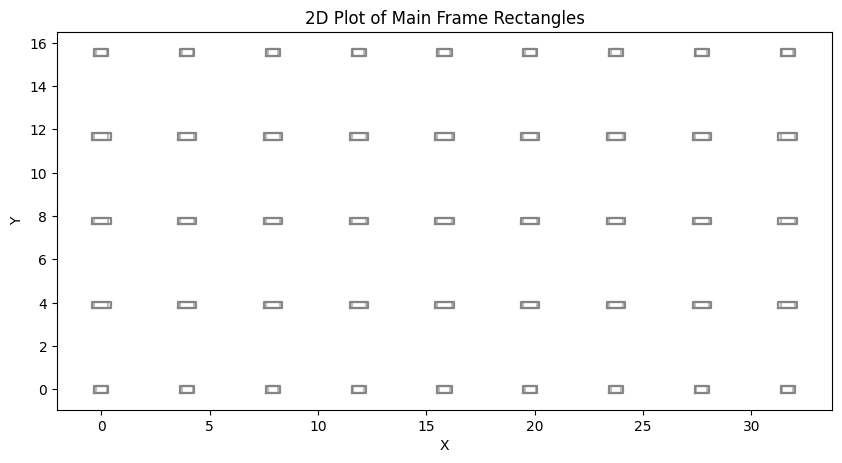

In [24]:
FLOOR: int = 0

# 2D plot of rectangles for all main frames
fig2, ax2 = plt.subplots(figsize=(10, 6))

frames =  data["frames"]["main_frames"]
for x in Bx:
    for y in By:
        frame_id = 0
        if y in {By[0], By[-1]}:
            frame_id = 1
        for col_id in frames[frame_id][0]["columns"][FLOOR]:
            section = data["sections"]["columns"][col_id]
            h = section["h"]
            b = section["b"]
            # Assume columns are at grid intersections (x, y) from Bx, By           
            plot_rectangle(ax2, x, y, h, b, style={"color": "gray", "alpha": 0.3})

ax2.set_aspect('equal')
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
plt.title('2D Plot of Main Frame Rectangles')
plt.show()